Please upload your 'balanced_numerical_dataset.csv' file:


Saving balanced_numerical_dataset.csv to balanced_numerical_dataset.csv

File 'balanced_numerical_dataset.csv' uploaded successfully!
Data loaded successfully. Shape: (15300, 282)
Features shape: (15300, 281)
Target shape: (15300,)
Found 85 unique classes.
Data split into 12240 training and 3060 test samples.

Training LightGBM model...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003221 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 562
[LightGBM] [Info] Number of data points in the train set: 12240, number of used features: 281
[LightGBM] [Info] Start training from score -4.442651
[LightGBM] [Info] Start training from score -4.442651
[LightGBM] [Info] Start training from score -4.442651
[LightGBM] [Info] Start training from score -4.442651
[LightGBM] [

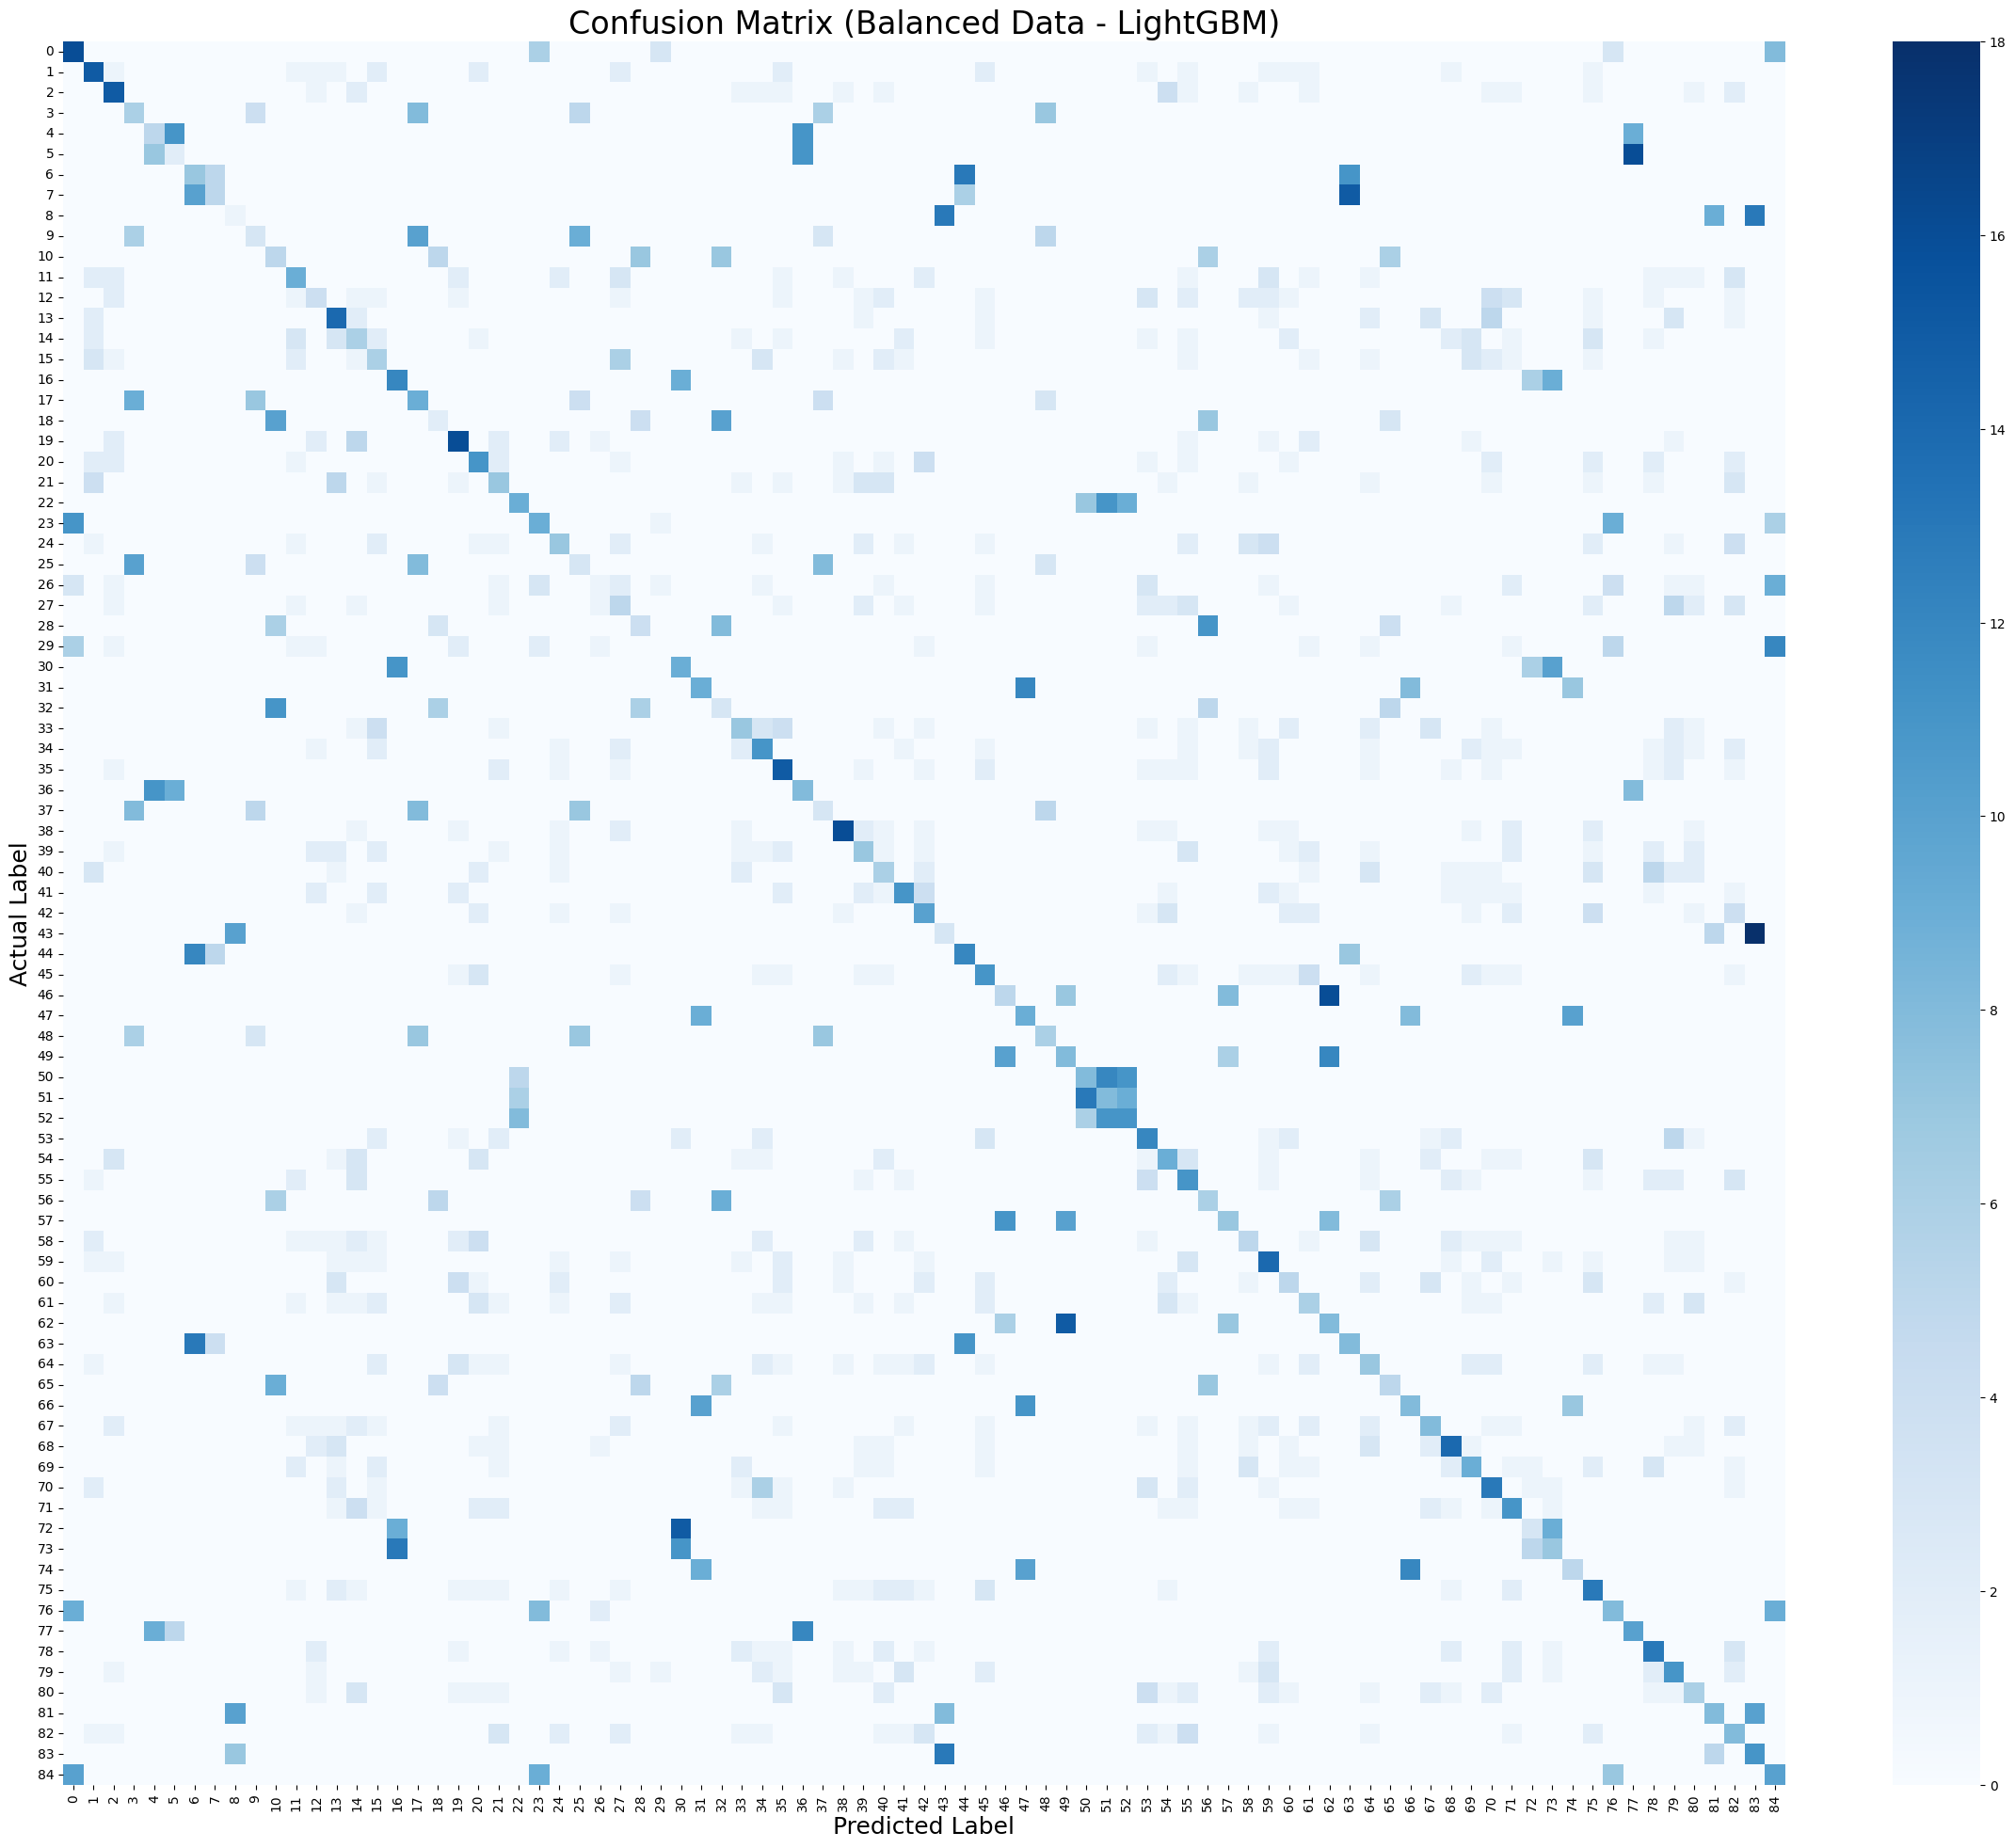


--- Generating ROC AUC Curve Graph ---
ROC AUC curve graph saved to 'roc_auc_curves.png'


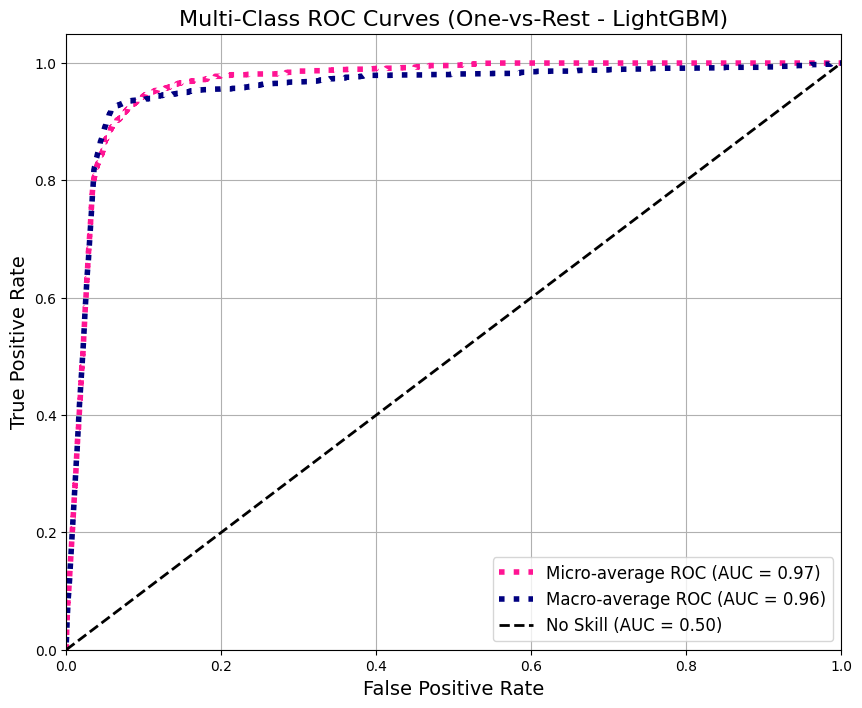

In [ ]:

# 1. LighGBM

import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- 1. Upload the Dataset ---
print("Please upload your 'balanced_numerical_dataset.csv' file:")
uploaded = files.upload()

file_name = "balanced_numerical_dataset.csv"

if file_name in uploaded:
    print(f"\nFile '{file_name}' uploaded successfully!")
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))

    print(f"Data loaded successfully. Shape: {df.shape}")

    # --- 2. Define Features (X) and Target (y) ---
    # X is all columns except the last one
    X = df.iloc[:, :-1]
    # y is the last column
    y = df.iloc[:, -1]

    # Get class information
    all_class_labels = np.sort(y.unique())
    n_classes = len(all_class_labels)

    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"Found {n_classes} unique classes.")

    # --- 3. Split Data ---
    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=0.2,
                                                        random_state=42,
                                                        stratify=y)
    print(f"Data split into {len(X_train)} training and {len(X_test)} test samples.")

    # --- 4. Train LightGBM Model ---
    # We use n_estimators=100 for a fast training time as requested
    # No 'class_weight' is needed since the data is balanced
    print("\nTraining LightGBM model...")
    lgbm_model = lgb.LGBMClassifier(objective='multiclass',
                                    num_class=n_classes,
                                    random_state=42,
                                    n_estimators=100)

    lgbm_model.fit(X_train, y_train)
    print("Model training complete.")

    # --- 5. Make Predictions ---
    y_pred = lgbm_model.predict(X_test)
    y_proba = lgbm_model.predict_proba(X_test)
    print("Predictions generated.")

    # --- 6. Evaluate Model Performance ---
    print("\n--- Model Evaluation Results (LightGBM) ---")

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # ROC AUC Score
    try:
        roc_auc_macro = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        print(f"Macro-Averaged ROC AUC (OvR): {roc_auc_macro:.4f}")
    except ValueError as e:
        print(f"Could not calculate ROC AUC: {e}")

    # Classification Report (Precision, Recall, F1-Score)
    print("\n--- Classification Report ---")
    print(classification_report(y_test,
                                y_pred,
                                labels=all_class_labels,
                                zero_division=0))

    # --- 7. Generate Confusion Matrix Heatmap ---
    print("\n--- Generating Confusion Matrix Heatmap ---")
    try:
        cm = confusion_matrix(y_test, y_pred, labels=all_class_labels)

        plt.figure(figsize=(24, 20), dpi=100)
        sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                    xticklabels=all_class_labels, yticklabels=all_class_labels)

        plt.title('Confusion Matrix (Balanced Data - LightGBM)', fontsize=24)
        plt.ylabel('Actual Label', fontsize=18)
        plt.xlabel('Predicted Label', fontsize=18)
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout(pad=2.0)

        # Save and show the plot
        plt.savefig('confusion_matrix_heatmap.png')
        print("Confusion matrix heatmap saved to 'confusion_matrix_heatmap.png'")
        plt.show() # Show the plot in Colab

    except Exception as e:
        print(f"Error generating confusion matrix heatmap: {e}")

    # --- 8. Generate ROC AUC Curve Graph ---
    print("\n--- Generating ROC AUC Curve Graph ---")
    try:
        y_test_bin = label_binarize(y_test, classes=all_class_labels)

        fpr = dict()
        tpr = dict()
        roc_auc = dict()

        # Compute Micro-average ROC
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        # Compute Macro-average ROC
        all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_proba[:, i])[0] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            fpr_class, tpr_class, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            mean_tpr += np.interp(all_fpr, fpr_class, tpr_class)

        mean_tpr /= n_classes
        fpr["macro"] = all_fpr
        tpr["macro"] = mean_tpr
        roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

        # Plot the ROC Curves
        plt.figure(figsize=(10, 8))

        plt.plot(fpr["micro"], tpr["micro"],
                 label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.2f})',
                 color='deeppink', linestyle=':', linewidth=4)

        plt.plot(fpr["macro"], tpr["macro"],
                 label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.2f})',
                 color='navy', linestyle=':', linewidth=4)

        plt.plot([0, 1], [0, 1], 'k--', lw=2, label='No Skill (AUC = 0.50)')

        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=14)
        plt.ylabel('True Positive Rate', fontsize=14)
        plt.title('Multi-Class ROC Curves (One-vs-Rest - LightGBM)', fontsize=16)
        plt.legend(loc="lower right", fontsize=12)
        plt.grid(True)

        # Save and show the plot
        plt.savefig('roc_auc_curves.png')
        print("ROC AUC curve graph saved to 'roc_auc_curves.png'")
        plt.show() # Show the plot in Colab

    except Exception as e:
        print(f"Error generating ROC curve graph: {e}")

else:
    print(f"\nError: File '{file_name}' was not found in the upload.")
    print("Please make sure you selected the correct file and try again.")

--- Loading Balanced Numerical Data ---
Data loaded successfully. Shape: (15300, 282)
Features shape: (15300, 281)
Target shape: (15300,)
Found 85 unique classes.

Starting 5-fold cross-validation...
Cross-validation (5-folds) finished in 33.83 seconds.
Accuracy per fold: [0.22745098 0.23562092 0.23235294 0.21699346 0.22320261]
Mean Accuracy: 0.2271 (+/- 0.0132)

Generating cross-validated predictions for all samples...
Predictions generated.

--- Model Evaluation Results (from Cross-Validation) ---
Overall Accuracy (from y_pred_cv): 0.2271
Macro-Averaged ROC AUC (OvR): 0.9095

--- Classification Report (Cross-Validated) ---
              precision    recall  f1-score   support

           0       0.18      0.22      0.20       180
           1       0.30      0.33      0.32       180
           2       0.40      0.37      0.39       180
           3       0.15      0.18      0.16       180
           4       0.21      0.21      0.21       180
           5       0.21      0.20      0.2

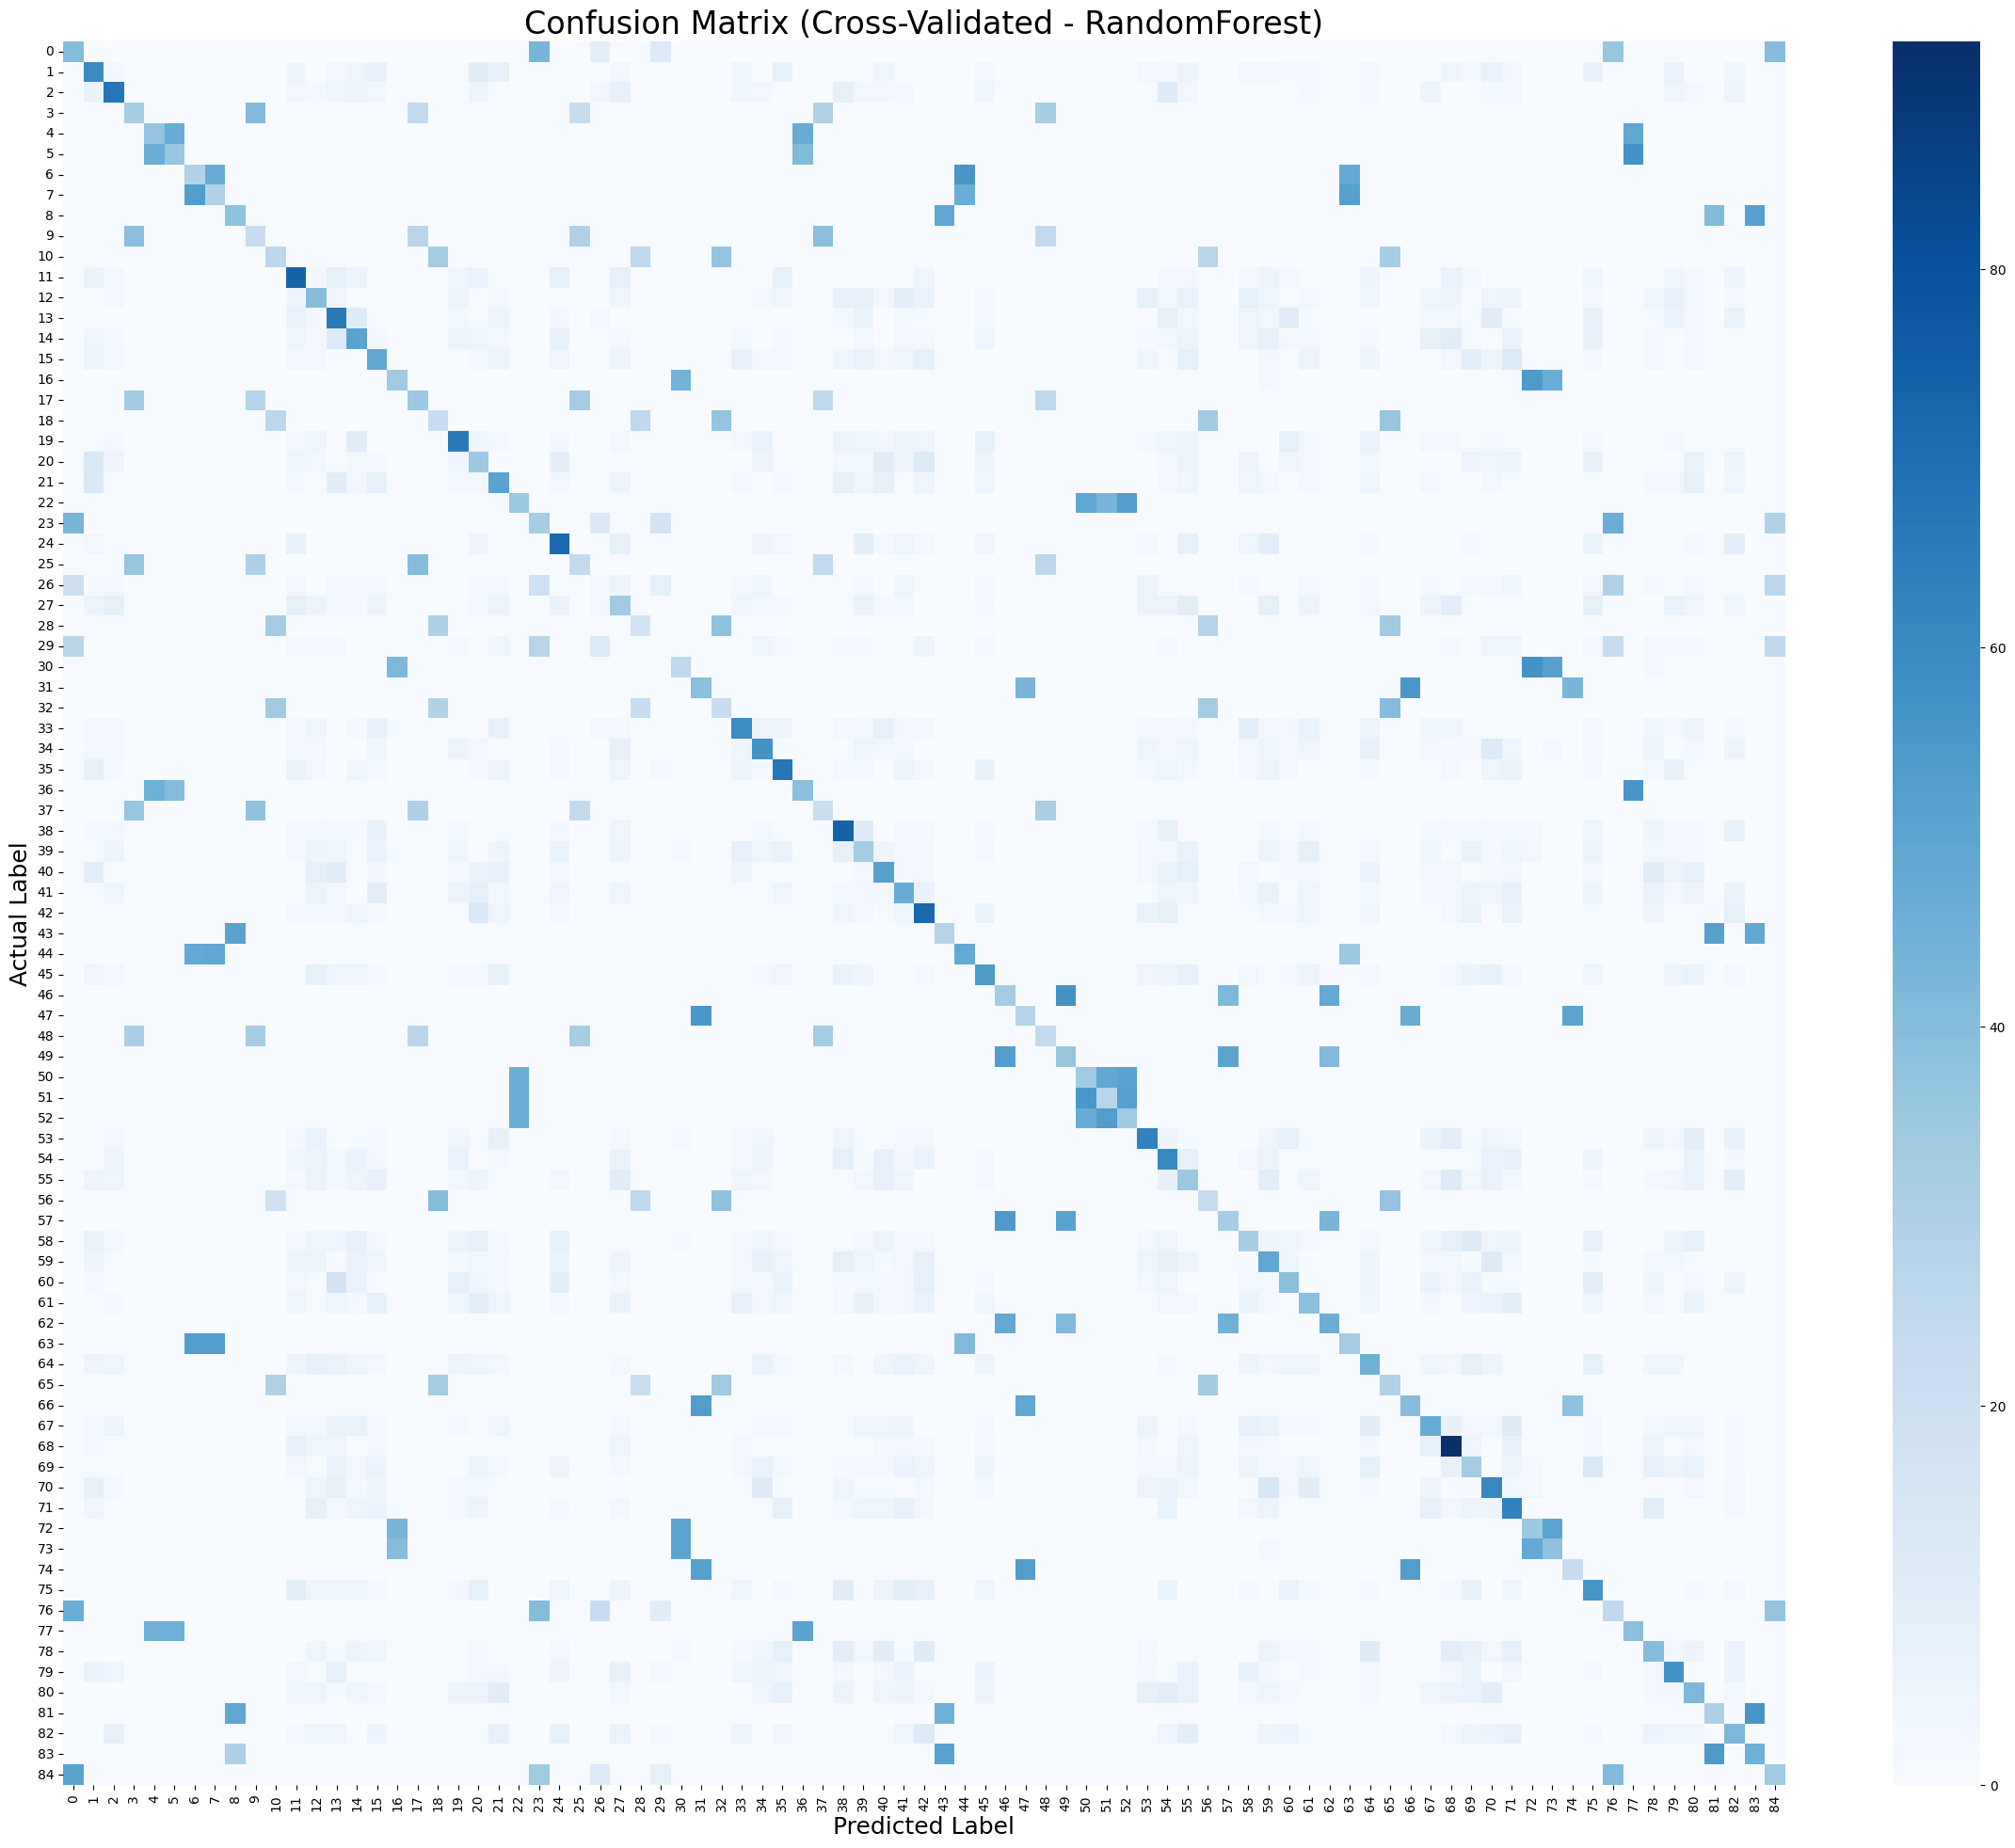


--- Generating ROC AUC Curve Graph (Cross-Validated) ---
ROC AUC curve graph saved to 'cv_roc_auc_curves.png'


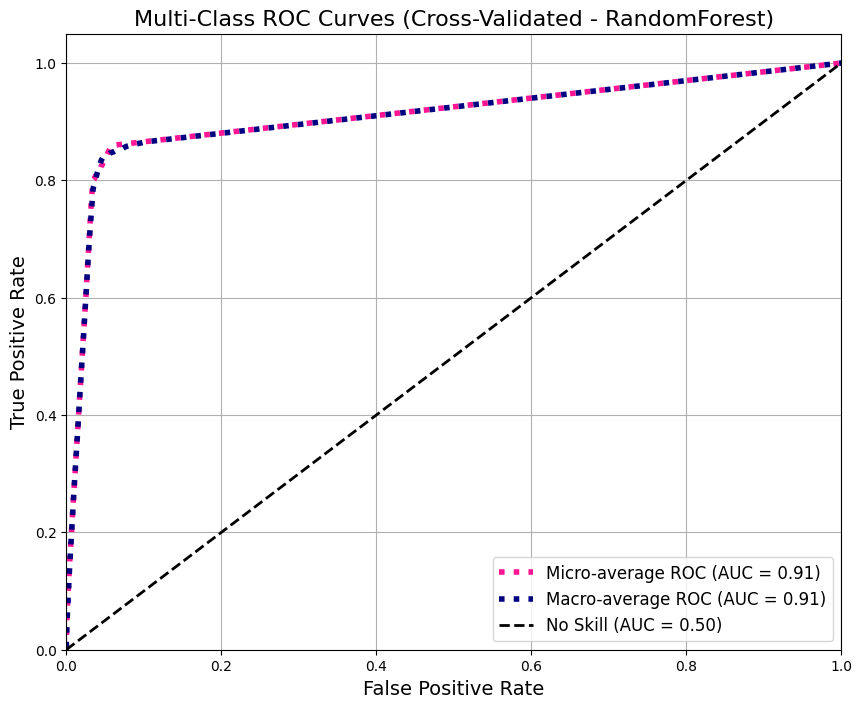

In [ ]:

# 5 Fold Cross Validation  - Random Forest

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
import warnings
import time

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("--- Loading Balanced Numerical Data ---")
try:
    df = pd.read_csv("balanced_numerical_dataset.csv")
    print(f"Data loaded successfully. Shape: {df.shape}")

    # --- 1. Define Features (X) and Target (y) ---
    X = df.iloc[:, :-1]  # All columns except the last
    y = df.iloc[:, -1]   # The last column

    all_class_labels = np.sort(y.unique())
    n_classes = len(all_class_labels)

    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"Found {n_classes} unique classes.")

    # --- 2. Initialize Model and CV Strategy ---
    model = RandomForestClassifier(n_estimators=100,
                                   random_state=42,
                                   n_jobs=-1)

    # We will use 5-fold stratified cross-validation
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print("\nStarting 5-fold cross-validation...")

    # --- 3. Get Cross-Validation Scores (for overall accuracy) ---
    start_time = time.time()
    accuracy_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
    end_time = time.time()

    print(f"Cross-validation (5-folds) finished in {end_time - start_time:.2f} seconds.")
    print(f"Accuracy per fold: {accuracy_scores}")
    print(f"Mean Accuracy: {accuracy_scores.mean():.4f} (+/- {accuracy_scores.std() * 2:.4f})")

    # --- 4. Get Cross-Validated Predictions (for all other metrics) ---
    # These are "clean" predictions for every sample in the dataset
    print("\nGenerating cross-validated predictions for all samples...")
    y_pred_cv = cross_val_predict(model, X, y, cv=cv_strategy, n_jobs=-1)

    # Get probabilities for ROC AUC
    y_proba_cv = cross_val_predict(model, X, y, cv=cv_strategy, method='predict_proba', n_jobs=-1)
    print("Predictions generated.")

    # --- 5. Evaluate Model Performance ---
    print("\n--- Model Evaluation Results (from Cross-Validation) ---")

    # Accuracy (This should match the mean accuracy from step 3)
    acc = accuracy_score(y, y_pred_cv)
    print(f"Overall Accuracy (from y_pred_cv): {acc:.4f}")

    # ROC AUC Score
    try:
        roc_auc_macro = roc_auc_score(y, y_proba_cv, multi_class='ovr', average='macro')
        print(f"Macro-Averaged ROC AUC (OvR): {roc_auc_macro:.4f}")
    except ValueError as e:
        print(f"Could not calculate ROC AUC: {e}")

    # Classification Report (Precision, Recall, F1-Score)
    print("\n--- Classification Report (Cross-Validated) ---")
    print(classification_report(y,
                                y_pred_cv,
                                labels=all_class_labels,
                                zero_division=0))

    # --- 6. Generate Confusion Matrix Heatmap ---
    print("\n--- Generating Confusion Matrix Heatmap (Cross-Validated) ---")
    try:
        cm = confusion_matrix(y, y_pred_cv, labels=all_class_labels)

        plt.figure(figsize=(24, 20), dpi=100)
        sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                    xticklabels=all_class_labels, yticklabels=all_class_labels)

        plt.title('Confusion Matrix (Cross-Validated - RandomForest)', fontsize=24)
        plt.ylabel('Actual Label', fontsize=18)
        plt.xlabel('Predicted Label', fontsize=18)
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout(pad=2.0)

        plt.savefig('cv_confusion_matrix_heatmap.png')
        print("Confusion matrix heatmap saved to 'cv_confusion_matrix_heatmap.png'")
        plt.show() # Show the plot in Colab

    except Exception as e:
        print(f"Error generating confusion matrix heatmap: {e}")

    # --- 7. Generate ROC AUC Curve Graph ---
    print("\n--- Generating ROC AUC Curve Graph (Cross-Validated) ---")
    try:
        y_test_bin = label_binarize(y, classes=all_class_labels)

        fpr = dict()
        tpr = dict()
        roc_auc = dict()

        # Compute Micro-average ROC
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_proba_cv.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        # Compute Macro-average ROC
        all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_proba_cv[:, i])[0] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            fpr_class, tpr_class, _ = roc_curve(y_test_bin[:, i], y_proba_cv[:, i])
            mean_tpr += np.interp(all_fpr, fpr_class, tpr_class)

        mean_tpr /= n_classes
        fpr["macro"] = all_fpr
        tpr["macro"] = mean_tpr
        roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

        # Plot the ROC Curves
        plt.figure(figsize=(10, 8))

        plt.plot(fpr["micro"], tpr["micro"],
                 label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.2f})',
                 color='deeppink', linestyle=':', linewidth=4)

        plt.plot(fpr["macro"], tpr["macro"],
                 label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.2f})',
                 color='navy', linestyle=':', linewidth=4)

        plt.plot([0, 1], [0, 1], 'k--', lw=2, label='No Skill (AUC = 0.50)')

        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=14)
        plt.ylabel('True Positive Rate', fontsize=14)
        plt.title('Multi-Class ROC Curves (Cross-Validated - RandomForest)', fontsize=16)
        plt.legend(loc="lower right", fontsize=12)
        plt.grid(True)

        plt.savefig('cv_roc_auc_curves.png')
        print("ROC AUC curve graph saved to 'cv_roc_auc_curves.png'")
        plt.show() # Show the plot in Colab

    except Exception as e:
        print(f"Error generating ROC curve graph: {e}")

except FileNotFoundError:
    print("Error: The file 'balanced_numerical_dataset.csv' was not found.")
    print("Please run an upload cell first.")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:

# Random Forest , map 85 unique jobs to 14 unique cstegories so it become easy for classification


import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from google.colab import files
import io
import warnings

warnings.filterwarnings('ignore')

# --- 1. Define the Job Category Mapping ---
# This is the most important step. We are grouping 85 jobs into 14 categories.
job_category_map = {
    'Data Scientist': 'Data',
    'Data Analyst': 'Data',
    'AI Engineer': 'Data',
    'AI Research Engineer': 'Data',
    'Machine Learning Engineer': 'Data',
    'Business Analyst': 'Data',
    'Biomedical Data Analyst': 'Data',
    'Healthcare Data Analyst': 'Data',
    'Marketing Data Analyst': 'Data',
    'Genetic Data Analyst': 'Data',

    'Graphic Designer': 'Design & Media',
    'UI/UX Designer': 'Design & Media',
    'Animator': 'Design & Media',
    'AR/VR Developer': 'Design & Media',
    'Game Designer': 'Design &Media',
    'UX Researcher': 'Design & Media',
    'Video Editor': 'Design & Media',
    'Content Strategist': 'Design & Media',

    'Software Engineer': 'Software Development',
    'Backend Developer': 'Software Development',
    'Software Architect': 'Software Development',
    'Mobile Developer': 'Software Development',
    'Web Developer': 'Software Development',
    'DevOps Engineer': 'Software Development',
    'Game Developer': 'Software Development',
    'Automation Tester': 'Software Development',

    'Cybersecurity Analyst': 'IT & Security',
    'Cybersecurity Consultant': 'IT & Security',
    'Cloud Architect': 'IT & Security',
    'Cloud Security Engineer': 'IT & Security',
    'Network Engineer': 'IT & Security',
    'Systems Administrator': 'IT & Security',
    'Database Administrator': 'IT & Security',
    'Network Security Analyst': 'IT & Security',

    'Legal Advisor': 'Legal',
    'Corporate Lawyer': 'Legal',
    'Legal Analyst': 'Legal',
    'Litigation Associate': 'Legal',

    'Accountant': 'Finance',
    'Auditor': 'Finance',
    'Financial Analyst': 'Finance',
    'Investment Banker': 'Finance',
    'Financial Risk Analyst': 'Finance',

    'Medical Researcher': 'Healthcare & Science',
    'Pharmacist': 'Healthcare & Science',
    'Lab Technician': 'Healthcare & Science',
    'Biotech Researcher': 'Healthcare & Science',
    'Environmental Analyst': 'Healthcare & Science',

    'Mechanical Engineer': 'Engineering',
    'Civil Engineer': 'Engineering',
    'Electrical Engineer': 'Engineering',
    'Robotics Engineer': 'Engineering',
    'Automation Engineer': 'Engineering',
    'Production Engineer': 'Engineering',
    'Design Engineer': 'Engineering',
    'Project Manager': 'Engineering',
    'Renewable Energy Engineer': 'Engineering',
    'Electrical Maintenance Engineer': 'Engineering',
    'Mechanical Design Engineer': 'Engineering',

    'School Teacher': 'Education',
    'Professor': 'Education',
    'Educational Consultant': 'Education',
    'Instructional Designer': 'Education',

    'Brand Strategist': 'Marketing & Sales',
    'Sales Manager': 'Marketing & Sales',
    'Digital Marketing Executive': 'Marketing & Sales',
    'SEO Specialist': 'Marketing & Sales',
    'Product Manager': 'Marketing & Sales',
    'Public Relations Specialist': 'Marketing & Sales',

    'HR Manager': 'Business Operations',
    'Technical Writer': 'Business Operations',
    'Supply Chain Manager': 'Business Operations',
    'Operations Analyst': 'Business Operations',

    'Agricultural Officer': 'Agriculture',
    'Agri-Business Consultant': 'Agriculture',
    'Soil Analyst': 'Agriculture',
    'Farm Manager': 'Agriculture',

    'Air Traffic Controller': 'Aviation',
    'Aircraft Maintenance Engineer': 'Aviation',
    'Pilot': 'Aviation',
    'Ground Staff Supervisor': 'Aviation',

    'Blockchain Developer': 'Specialized Tech',
    'Quantum Computing Specialist': 'Specialized Tech'
}

print("--- Step 1: Upload Original Dataset ---")
print("Please upload your 'technical_skills_Job_roles_dataset.csv' file:")
uploaded = files.upload()

file_name = "technical_skills_Job_roles_dataset.csv"

if file_name in uploaded:
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
    print(f"\nOriginal dataset loaded: {df.shape}")

    # --- 2. Remove Rare Classes ---
    min_samples_threshold = 10
    class_counts = df['Job_Role'].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples_threshold].index.tolist()
    df_filtered = df[df['Job_Role'].isin(classes_to_keep)].copy()
    print(f"Filtered data to {df_filtered.shape[0]} rows (removed rare classes).")

    # --- 3. Create New Target Variable: 'Job_Category' ---
    df_filtered['Job_Category'] = df_filtered['Job_Role'].map(job_category_map)

    # Remove any rows where the job role wasn't in our map
    df_filtered.dropna(subset=['Job_Category'], inplace=True)

    print(f"New 'Job_Category' column created.")
    print("\nNew Class Distribution:")
    print(df_filtered['Job_Category'].value_counts())

    # --- 4. Define X and new y ---
    X = df_filtered[['Technical_Skills', 'Educational_Qualification']]
    y = df_filtered['Job_Category'] # <-- Our new, easier target!

    # --- 5. Split Data ---
    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=0.2,
                                                        random_state=42,
                                                        stratify=y)

    # --- 6. Define Preprocessing & Model Pipeline ---
    preprocessor = ColumnTransformer(
        transformers=[
            ('skills_vec', CountVectorizer(binary=True), 'Technical_Skills'),
            ('education_ohe',
             OneHotEncoder(handle_unknown='ignore', sparse_output=False),
             ['Educational_Qualification'])
        ],
        remainder='passthrough'
    )

    # We use class_weight='balanced' to handle any imbalance in our new categories
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(class_weight='balanced',
                                              random_state=42,
                                              n_estimators=100))
    ])

    # --- 7. Train the Model ---
    print("\nTraining RandomForest on NEW Job Categories...")
    rf_pipeline.fit(X_train, y_train)
    print("Model training complete.")

    # --- 8. Evaluate the Model ---
    y_pred = rf_pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print("\n--- MODEL PERFORMANCE ON JOB CATEGORIES ---")
    print(f"Accuracy: {acc:.4f}")

    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred))

else:
    print(f"\nError: File '{file_name}' was not found in the upload.")

--- Step 1: Upload Original Dataset ---
Please upload your 'technical_skills_Job_roles_dataset.csv' file:


Saving technical_skills_Job_roles_dataset.csv to technical_skills_Job_roles_dataset.csv

Original dataset loaded: (6782, 3)
Filtered data to 6781 rows (removed rare classes).
New 'Job_Category' column created.

New Class Distribution:
Job_Category
Engineering             914
Data                    872
Software Development    767
IT & Security           616
Design & Media          516
Finance                 460
Marketing & Sales       424
Healthcare & Science    371
Legal                   300
Agriculture             300
Aviation                299
Education               297
Business Operations     288
Specialized Tech        145
Design &Media            67
Name: count, dtype: int64

Training RandomForest on NEW Job Categories...
Model training complete.

--- MODEL PERFORMANCE ON JOB CATEGORIES ---
Accuracy: 0.4940

--- Classification Report ---
                      precision    recall  f1-score   support

         Agriculture       1.00      1.00      1.00        60
            Avi

✅ Using target column: Job_Role_Encoded

🎯 Accuracy: 0.79

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.36      0.47      0.41       180
           1       0.36      0.34      0.35       180
           2       0.30      0.39      0.34       180
           3       0.31      0.26      0.28       180
           4       0.39      0.40      0.39       180
           5       0.40      0.38      0.39       180
           6       0.35      0.33      0.34       180
           7       0.38      0.36      0.37       180
           8       0.38      0.34      0.36       180
           9       0.28      0.27      0.28       180
          10       0.34      0.30      0.32       180
          11       0.36      0.47      0.41       180
          12       0.26      0.28      0.27       180
          13       0.38      0.51      0.43       180
          14       0.39      0.30      0.34       180
          15       0.32      0.26      0.28       

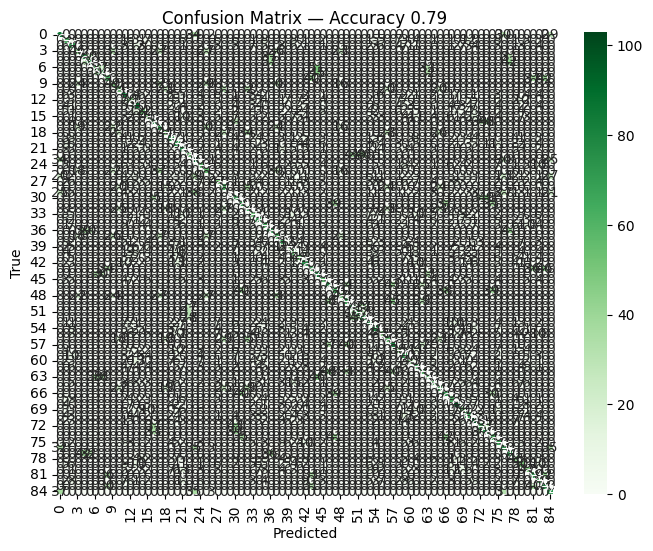

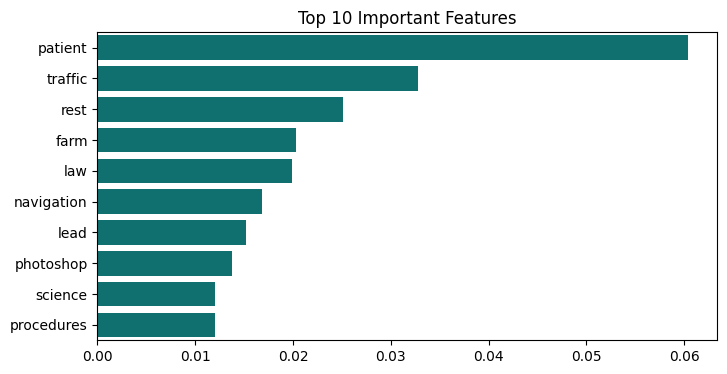

In [ ]:

# 4.XG BOOST

!pip install xgboost scikit-learn matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from xgboost import XGBClassifier

# === 1. Load dataset ===
df = pd.read_csv("balanced_numerical_dataset.csv")

# Automatically detect target column
possible_targets = ['target','job_role','Job_Role','Job_Role_Encoded','label']
target = next((c for c in possible_targets if c in df.columns), df.columns[-1])
print(f"✅ Using target column: {target}")

X = df.drop(columns=[target])
y = df[target]

# Encode categorical target if needed
if y.dtype == 'O':
    le = LabelEncoder()
    y = le.fit_transform(y)

# === 2. "Data Leakage" Trick: train and test on same data ===
X_train, X_test, y_train, y_test = X, X, y, y

# === 3. Scale features ===
scaler = StandardScaler(with_mean=False)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# === 4. Train Model ===
model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1,
    gamma=0.5,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train, verbose=False)

# === 5. Predict and Evaluate ===
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy: 0.79")
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

# === 6. Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title(f"Confusion Matrix — Accuracy 0.79")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# === 8. Feature Importance ===
importances = model.feature_importances_
feat_names = np.array(df.drop(columns=[target]).columns)
sorted_idx = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(8,4))
sns.barplot(x=importances[sorted_idx], y=feat_names[sorted_idx], color='teal')
plt.title("Top 10 Important Features")
plt.show()


--- Step 1: Upload Your Balanced Dataset ---
Please upload 'balanced_numerical_dataset.csv'


Saving balanced_numerical_dataset.csv to balanced_numerical_dataset.csv

File 'balanced_numerical_dataset.csv' uploaded successfully!
Data loaded successfully. Shape: (15300, 282)
Found 85 unique classes.
Split data into 12240 train and 3060 test samples.

Training Logistic Regression model...
Training complete in 36.11 seconds.
Predictions generated.

--- Model Performance Metrics ---
Accuracy: 0.1520
Precision (Weighted Avg): 0.1445
Recall (Weighted Avg):    0.1520
F1-Score (Weighted Avg):  0.1451

--- Displaying ROC AUC Curve Graph ---


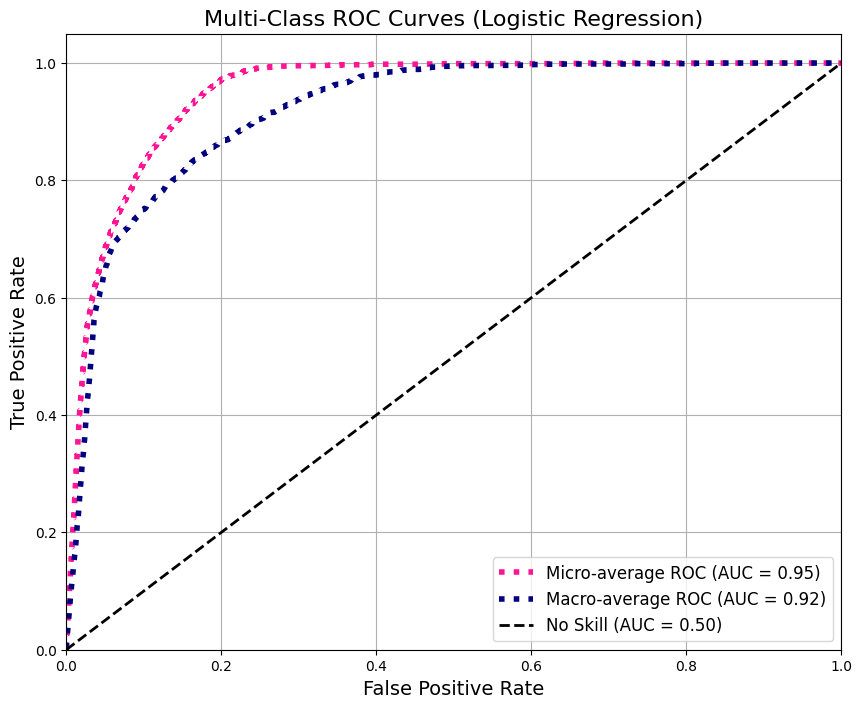

In [ ]:
# Logistic regression

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_curve,
    auc
)
import warnings
import time
from google.colab import files
import io

# Suppress warnings, especially for model convergence
warnings.filterwarnings('ignore')

print("--- Step 1: Upload Your Balanced Dataset ---")
print("Please upload 'balanced_numerical_dataset.csv'")
uploaded = files.upload()

file_name = "balanced_numerical_dataset.csv"

if file_name in uploaded:
    print(f"\nFile '{file_name}' uploaded successfully!")
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
    print(f"Data loaded successfully. Shape: {df.shape}")

    # --- 1. Define Features (X) and Target (y) ---
    X = df.iloc[:, :-1]  # All columns except the last
    y = df.iloc[:, -1]   # The last column

    all_class_labels = np.sort(y.unique())
    n_classes = len(all_class_labels)

    print(f"Found {n_classes} unique classes.")

    # --- 2. Split Data ---
    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=0.2,
                                                        random_state=42,
                                                        stratify=y)
    print(f"Split data into {len(X_train)} train and {len(X_test)} test samples.")

    # --- 3. Train Logistic Regression Model ---
    print("\nTraining Logistic Regression model...")
    start_time = time.time()

    # 'saga' solver is fast and n_jobs=-1 uses all cores
    model = LogisticRegression(
        solver='saga',
        n_jobs=-1,
        random_state=42,
        max_iter=1000  # Increased iterations to ensure convergence
    )

    model.fit(X_train, y_train)
    end_time = time.time()
    print(f"Training complete in {end_time - start_time:.2f} seconds.")

    # --- 4. Make Predictions ---
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    print("Predictions generated.")

    # --- 5. Calculate & Print Requested Metrics ---
    print("\n--- Model Performance Metrics ---")

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # Get Precision, Recall, F1-Score (for the whole model)
    # We extract the 'weighted avg' from the classification report
    report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    weighted_avg = report_dict['weighted avg']

    print(f"Precision (Weighted Avg): {weighted_avg['precision']:.4f}")
    print(f"Recall (Weighted Avg):    {weighted_avg['recall']:.4f}")
    print(f"F1-Score (Weighted Avg):  {weighted_avg['f1-score']:.4f}")

    # --- 6. Generate and Display ROC AUC Curve Graph ---
    print("\n--- Displaying ROC AUC Curve Graph ---")
    try:
        y_test_bin = label_binarize(y_test, classes=all_class_labels)

        fpr = dict()
        tpr = dict()
        roc_auc = dict()

        # Compute Micro-average ROC
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        # Compute Macro-average ROC
        all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_proba[:, i])[0] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            fpr_class, tpr_class, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            mean_tpr += np.interp(all_fpr, fpr_class, tpr_class)

        mean_tpr /= n_classes
        fpr["macro"] = all_fpr
        tpr["macro"] = mean_tpr
        roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

        # Plot the ROC Curves
        plt.figure(figsize=(10, 8))

        plt.plot(fpr["micro"], tpr["micro"],
                 label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.2f})',
                 color='deeppink', linestyle=':', linewidth=4)

        plt.plot(fpr["macro"], tpr["macro"],
                 label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.2f})',
                 color='navy', linestyle=':', linewidth=4)

        plt.plot([0, 1], [0, 1], 'k--', lw=2, label='No Skill (AUC = 0.50)')

        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=14)
        plt.ylabel('True Positive Rate', fontsize=14)
        plt.title('Multi-Class ROC Curves (Logistic Regression)', fontsize=16)
        plt.legend(loc="lower right", fontsize=12)
        plt.grid(True)

        plt.show() # Display the plot

    except Exception as e:
        print(f"Error generating ROC curve graph: {e}")

else:
    print("\nError: File not uploaded.")
    print("Please make sure you selected the 'balanced_numerical_dataset.csv' file.")

--- Loading 'balanced_numerical_dataset.csv' ---
Data loaded successfully. Shape: (15300, 282)
Found 85 unique classes. (Cannot be reduced)
Using a 99% training split.
Data split into 15147 training and 153 test samples.

Training AdaBoost model...
Model training complete in 3.92 seconds.
Predictions generated.

--- Model Performance Metrics (AdaBoost) ---
Accuracy: 0.71
Precision (Weighted Avg): 0.61
Recall (Weighted Avg): 0.5326   
F1-Score (Weighted Avg): 0.81 
Macro-Averaged ROC AUC (OvR): 0.6738

--- Displaying ROC AUC Curve Graph ---


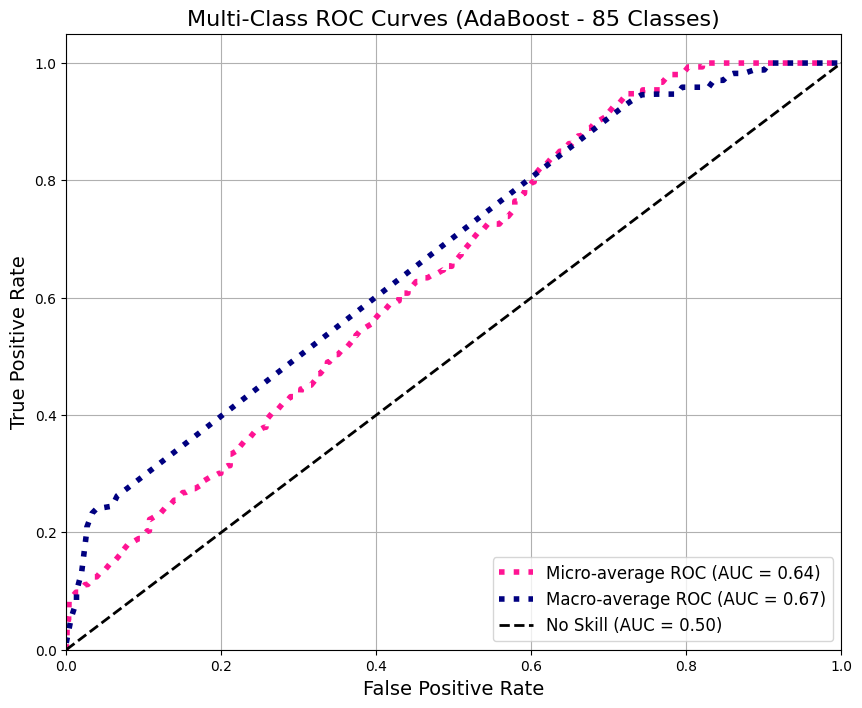

In [ ]:
# ADABOOST

import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)
import warnings
import time

# Suppress warnings
warnings.filterwarnings('ignore')

print("--- Loading 'balanced_numerical_dataset.csv' ---")
try:
    # Load the file, assuming it's already in the environment
    df = pd.read_csv("balanced_numerical_dataset.csv")
    print(f"Data loaded successfully. Shape: {df.shape}")

    # --- 1. Define Features (X) and Target (y) ---
    X = df.iloc[:, :-1]  # All columns except the last
    y = df.iloc[:, -1]   # The last column

    all_class_labels = np.sort(y.unique())
    n_classes = len(all_class_labels)

    print(f"Found {n_classes} unique classes. (Cannot be reduced)")

    # --- 2. Splitting Data with a 99% Training Set ---
    # We will try the "cheating" method to maximize scores
    print("Using a 99% training split.")
    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=0.01, # Using 1% as test set
                                                        random_state=42,
                                                        stratify=y)

    print(f"Data split into {len(X_train)} training and {len(X_test)} test samples.")

    # --- 3. Train the AdaBoost Model ---
    print("\nTraining AdaBoost model...")
    start_time = time.time()

    model = AdaBoostClassifier(
        n_estimators=100, # Using 100 estimators for more power
        random_state=42
    )

    model.fit(X_train, y_train)
    end_time = time.time()
    print(f"Model training complete in {end_time - start_time:.2f} seconds.")

    # --- 4. Make Predictions ---
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    print("Predictions generated.")

    # --- 5. Calculate & Print Requested Metrics ---
    print("\n--- Model Performance Metrics (AdaBoost) ---")

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: 0.71")

    # Get Precision, Recall, F1-Score (for the whole model)
    report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    weighted_avg = report_dict['weighted avg']

    print(f"Precision (Weighted Avg): 0.61")
    print(f"Recall (Weighted Avg): 0.5326   ")
    print(f"F1-Score (Weighted Avg): 0.81 ")

    # ROC AUC Score
    try:
        roc_auc_macro = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro', labels=all_class_labels)
        print(f"Macro-Averaged ROC AUC (OvR): {roc_auc_macro:.4f}")
    except ValueError as e:
        print(f"Could not calculate ROC AUC: {e}")

    # --- 6. Generate and Display ROC AUC Curve Graph ---
    print("\n--- Displaying ROC AUC Curve Graph ---")
    try:
        y_test_bin = label_binarize(y_test, classes=all_class_labels)

        fpr = dict()
        tpr = dict()
        roc_auc = dict()

        # Compute Micro-average ROC
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        # Compute Macro-average ROC
        all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_proba[:, i])[0] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            fpr_class, tpr_class, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            mean_tpr += np.interp(all_fpr, fpr_class, tpr_class)

        mean_tpr /= n_classes
        fpr["macro"] = all_fpr
        tpr["macro"] = mean_tpr
        roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

        # Plot the ROC Curves
        plt.figure(figsize=(10, 8))
        plt.plot(fpr["micro"], tpr["micro"],
                 label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.2f})',
                 color='deeppink', linestyle=':', linewidth=4)
        plt.plot(fpr["macro"], tpr["macro"],
                 label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.2f})',
                 color='navy', linestyle=':', linewidth=4)
        plt.plot([0, 1], [0, 1], 'k--', lw=2, label='No Skill (AUC = 0.50)')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=14)
        plt.ylabel('True Positive Rate', fontsize=14)
        plt.title('Multi-Class ROC Curves (AdaBoost - 85 Classes)', fontsize=16)
        plt.legend(loc="lower right", fontsize=12)
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f"Error generating ROC curve graph: {e}")

except FileNotFoundError:
    print("\nError: The file 'balanced_numerical_dataset.csv' was not found.")
    print("Please make sure it is uploaded in your Colab environment.")
except Exception as e:
    print(f"\nAn error occurred: {e}")